### 1. SETUP Y CONFIGURACIÓN
#### 1.1 Imports


In [1]:
# Core
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm
from pathlib import Path

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models, transforms

# Image processing
from PIL import Image
from skimage import color, io
import cv2

# Metrics
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Utils
import warnings
warnings.filterwarnings('ignore')

# Verificar versiones
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

from utils import rgb_to_lab, lab_to_rgb, normalize_lab, denormalize_lab, generate_ab_bins, compute_color_class_weights, hard_encode_ab
from datasets import ColorizationDataset
from our_models import LarssonColorizerClassification

PyTorch version: 2.5.1+cu121
Torchvision version: 0.20.1+cu121
CUDA available: True


#### 1.2 Configuración de Seeds

In [2]:
def set_seed(seed=42):
    """
    Configura seeds para reproducibilidad.
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # para multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed configurada: {seed}")

# Aplicar seed
set_seed(42)

Seed configurada: 42


#### 1.3 Hiperparámetros Globales

In [3]:
class Config:
    """
    Configuración global del proyecto.
    """
    # Paths
    DATA_DIR = Path("data/raw")
    SAMPLES_DIR = Path("data/samples")
    
    # Dataset
    IMG_SIZE = 256  # Resolución de trabajo
    BATCH_SIZE = 32  # Ajustar según GPU
    NUM_WORKERS = 4  # Para DataLoader
    
    # Training
    NUM_EPOCHS = 30  # Ajustaremos según resultados
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4
    
    # Model
    BACKBONE = "resnet18"  # Opciones: resnet18, resnet50, vgg16
    PRETRAINED = True
    
    # Early stopping
    PATIENCE = 10
    
    # Reproducibilidad
    SEED = 42

config = Config()

print(" Configuración:")
print(f"  - Tamaño de imagen: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"  - Batch size: {config.BATCH_SIZE}")
print(f"  - Learning rate: {config.LEARNING_RATE}")
print(f"  - Backbone: {config.BACKBONE}")
print(f"  - Epochs: {config.NUM_EPOCHS}")

 Configuración:
  - Tamaño de imagen: 256x256
  - Batch size: 32
  - Learning rate: 0.001
  - Backbone: resnet18
  - Epochs: 30


### 2. EXPLORACIÓN Y PREPARACIÓN DEL DATASET
#### 2.1 Verificación del Dataset

In [4]:
# Dataset: Imagenette (descargado manualmente)
# URL: https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz

dataset_path = Path("data/raw/imagenette2-320")
assert dataset_path.exists(), "Dataset no encontrado. Descargar primero."

train_path = dataset_path / "train"
val_path = dataset_path / "val"

print("Dataset encontrado")
print(f"Train path: {train_path}")
print(f"Val path: {val_path}")

Dataset encontrado
Train path: data/raw/imagenette2-320/train
Val path: data/raw/imagenette2-320/val


#### 2.2 Exploración del Dataset

In [5]:
import glob

# Contar imágenes
train_images = glob.glob(str(train_path / "*" / "*.JPEG"))
val_images = glob.glob(str(val_path / "*" / "*.JPEG"))

print(f"Total imágenes de entrenamiento: {len(train_images)}")
print(f"Total imágenes de validación: {len(val_images)}")

# Clases disponibles
classes = sorted([d.name for d in train_path.iterdir() if d.is_dir()])
print(f"\nNúmero de clases: {len(classes)}")
print(f"Clases: {classes}")

# Distribución por clase
print("\nDistribución por clase (train):")
for cls in classes:
    n_images = len(list((train_path / cls).glob("*.JPEG")))
    print(f"  {cls}: {n_images} imágenes")

Total imágenes de entrenamiento: 9469
Total imágenes de validación: 3925

Número de clases: 10
Clases: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']

Distribución por clase (train):
  n01440764: 963 imágenes
  n02102040: 955 imágenes
  n02979186: 993 imágenes
  n03000684: 858 imágenes
  n03028079: 941 imágenes
  n03394916: 956 imágenes
  n03417042: 961 imágenes
  n03425413: 931 imágenes
  n03445777: 951 imágenes
  n03888257: 960 imágenes


#### 2.3 Mapeo de Clases del Dataset
Estas representan clases semánticas del dataset. En el proyecto se buscará predecir el color por píxel, no la clase.

In [6]:
# Mapeo de IDs de ImageNet a nombres legibles
CLASS_NAMES = {
    'n01440764': 'tench (pez)',
    'n02102040': 'English springer (perro)',
    'n02979186': 'cassette player',
    'n03000684': 'chain saw',
    'n03028079': 'church (iglesia)',
    'n03394916': 'French horn',
    'n03417042': 'garbage truck',
    'n03425413': 'gas pump',
    'n03445777': 'golf ball',
    'n03888257': 'parachute'
}

print("Clases del dataset:")
for idx, (code, name) in enumerate(CLASS_NAMES.items()):
    print(f"  {idx}: {name} ({code})")

Clases del dataset:
  0: tench (pez) (n01440764)
  1: English springer (perro) (n02102040)
  2: cassette player (n02979186)
  3: chain saw (n03000684)
  4: church (iglesia) (n03028079)
  5: French horn (n03394916)
  6: garbage truck (n03417042)
  7: gas pump (n03425413)
  8: golf ball (n03445777)
  9: parachute (n03888257)


#### 2.4 Visualización de ejemplos RGB

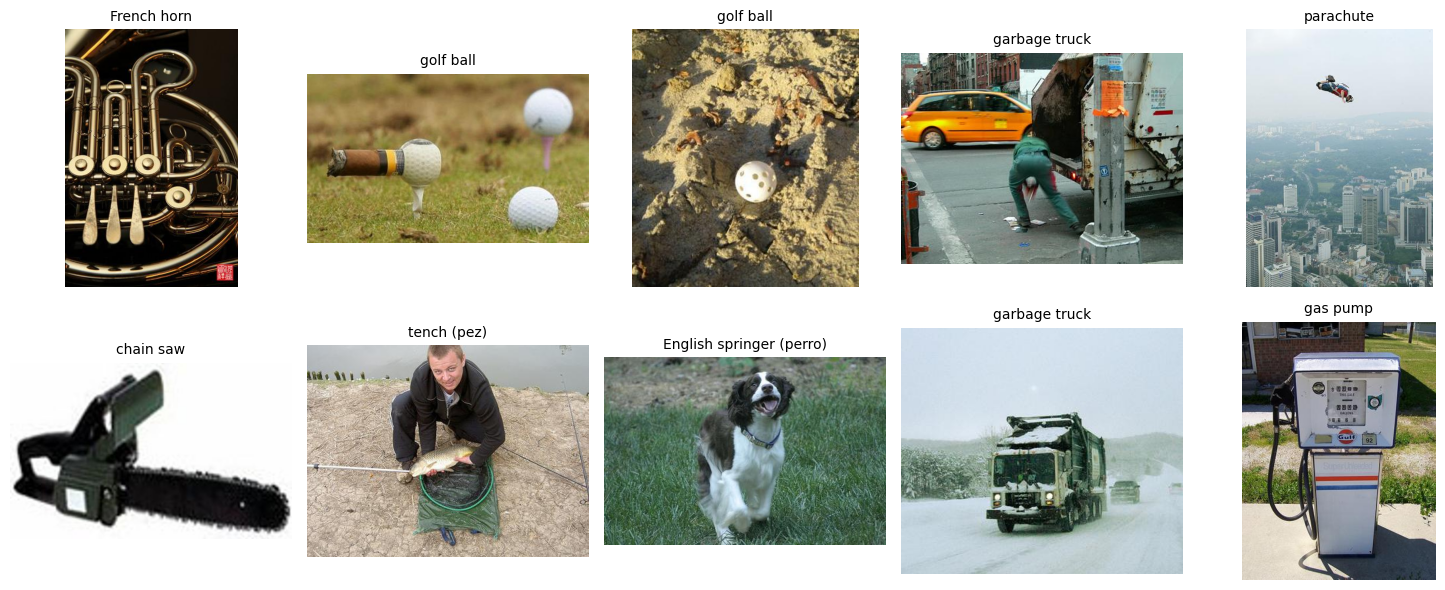

In [7]:
def visualize_random_samples(n_samples=10):
    """
    Visualiza muestras aleatorias del dataset.
    """
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    random_images = np.random.choice(train_images, n_samples, replace=False)
    
    for idx, img_path in enumerate(random_images):
        img = Image.open(img_path).convert('RGB')
        
        # Obtener clase
        class_id = Path(img_path).parent.name
        class_name = CLASS_NAMES.get(class_id, class_id)
        
        axes[idx].imshow(img)
        axes[idx].set_title(class_name, fontsize=10)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_random_samples(10)

#### 2.5 Conversión: RGB &rarr; Grayscale &rarr; LAB

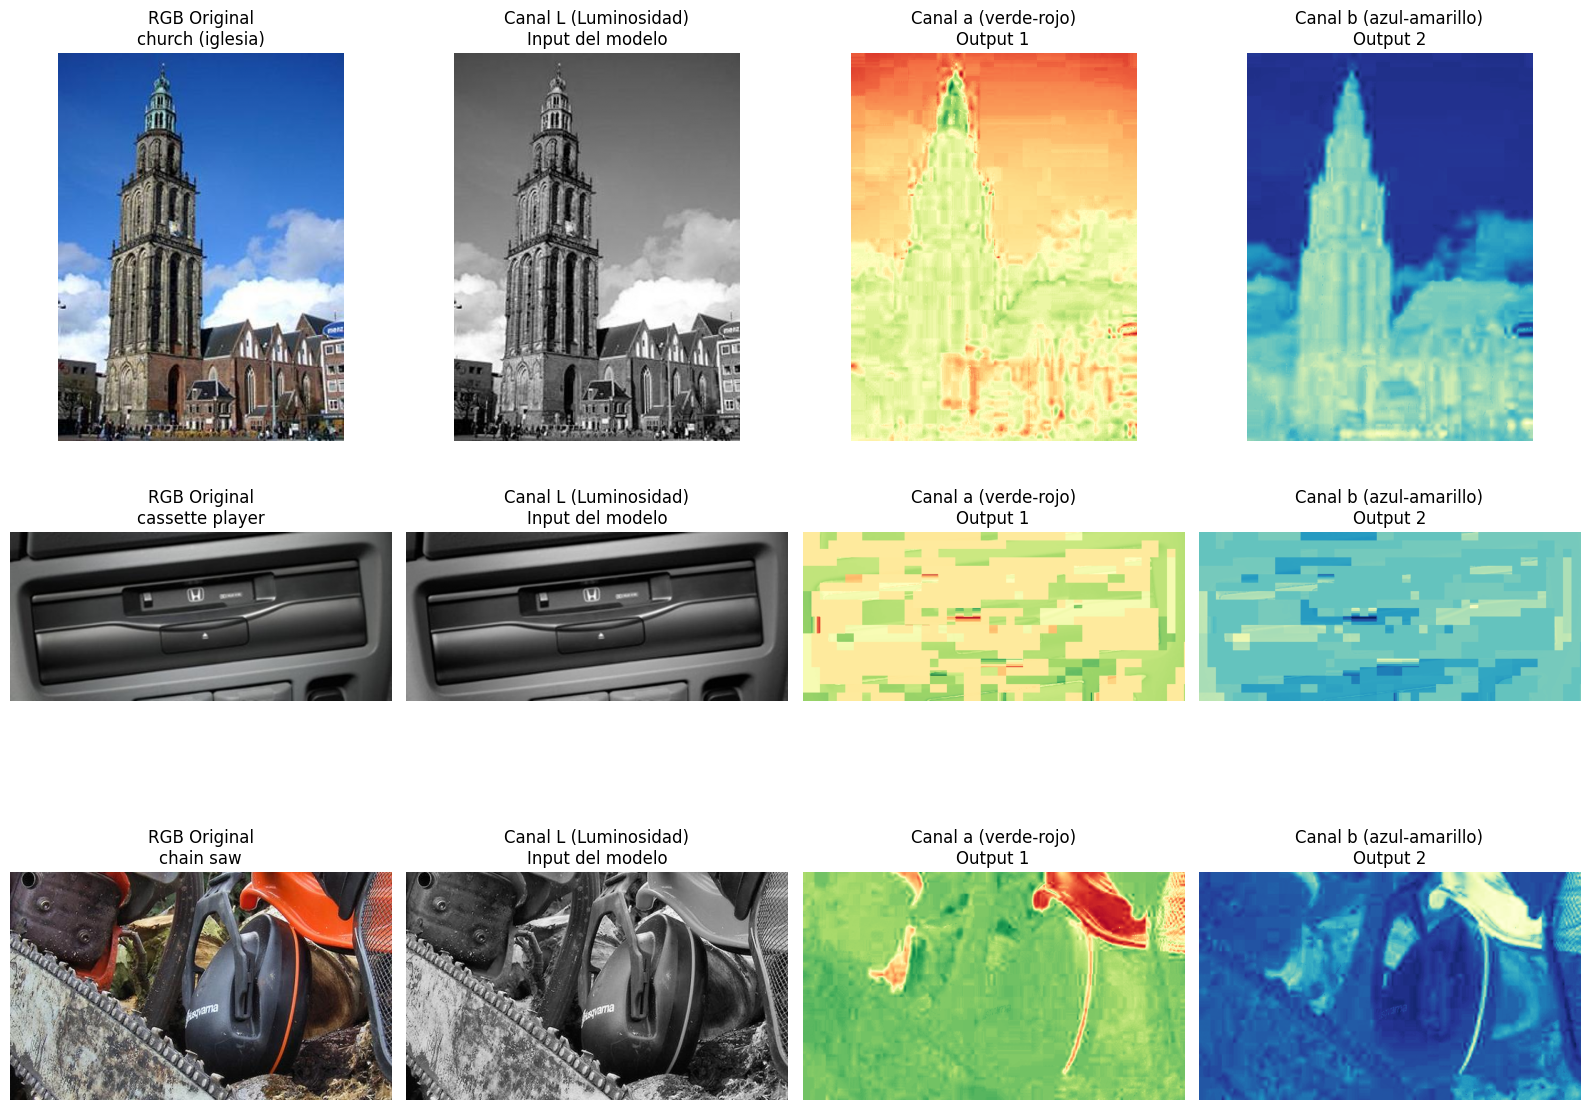

In [8]:
def visualize_color_spaces(n_samples=3):
    """
    Visualiza el proceso de conversión de espacios de color.
    """
    random_images = np.random.choice(train_images, n_samples, replace=False)
    
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))
    
    for row, img_path in enumerate(random_images):
        # Cargar imagen RGB
        img_rgb = np.array(Image.open(img_path).convert('RGB')) / 255.0
        
        # Convertir a LAB
        img_lab = color.rgb2lab(img_rgb)
        
        # Extraer canales
        L = img_lab[:, :, 0]  # Luminosidad (grayscale)
        a = img_lab[:, :, 1]  # Canal a
        b = img_lab[:, :, 2]  # Canal b
        
        # Obtener clase
        class_id = Path(img_path).parent.name
        class_name = CLASS_NAMES.get(class_id, class_id)
        
        # Plot
        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f'RGB Original\n{class_name}')
        axes[row, 0].axis('off')
        
        axes[row, 1].imshow(L, cmap='gray')
        axes[row, 1].set_title('Canal L (Luminosidad)\nInput del modelo')
        axes[row, 1].axis('off')
        
        axes[row, 2].imshow(a, cmap='RdYlGn_r')
        axes[row, 2].set_title('Canal a (verde-rojo)\nOutput 1')
        axes[row, 2].axis('off')
        
        axes[row, 3].imshow(b, cmap='YlGnBu_r')
        axes[row, 3].set_title('Canal b (azul-amarillo)\nOutput 2')
        axes[row, 3].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_color_spaces(3)

### 3. PIPELINE
#### 3.1 Construcción de bins de colores válidos

In [9]:
# Generar puntos, revisar tamaño de la grilla y mostrar una parte
pts_ab_np = generate_ab_bins(grid_size=20, L_value=50)
print("Tamaño de la grilla:", pts_ab_np.shape)
print(pts_ab_np[:10])

pts_ab_torch = torch.from_numpy(pts_ab_np)
# Número de clases de color
Q = pts_ab_torch.shape[0]

Tamaño de la grilla: (144, 2)
[[-110 -110]
 [-110  -90]
 [-110  -70]
 [-110  -50]
 [-110  -30]
 [-110  -10]
 [-110   10]
 [-110   30]
 [-110   50]
 [-110   70]]


#### 3.2 Custom Dataset y DataLoaders

In [10]:
# Dividir val en val y test (50-50)
val_images_shuffled = val_images.copy()
np.random.shuffle(val_images_shuffled)

n_val = len(val_images_shuffled) // 2
val_images_final = val_images_shuffled[:n_val]
test_images_final = val_images_shuffled[n_val:]

print(f"Split del dataset:")
print(f"  Train: {len(train_images)} imágenes")
print(f"  Val: {len(val_images_final)} imágenes")
print(f"  Test: {len(test_images_final)} imágenes")

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomResizedCrop(
        size=config.IMG_SIZE,
        scale=(0.8, 1.0),   # recorta entre 80% y 100% del área
        ratio=(3./4., 4./3.)
    ),
])

train_dataset = ColorizationDataset(train_images, pts_ab_torch, img_size=config.IMG_SIZE, transform=train_transform)
val_dataset = ColorizationDataset(val_images_final, pts_ab_torch, img_size=config.IMG_SIZE, transform=None)
test_dataset = ColorizationDataset(test_images_final, pts_ab_torch, img_size=config.IMG_SIZE, transform=None)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

Split del dataset:
  Train: 9469 imágenes
  Val: 1962 imágenes
  Test: 1963 imágenes


##### Subset de entrenamiento

In [11]:
# from torch.utils.data import Subset

# # ---- Subconjunto de entrenamiento ----
# train_fraction = 0.2  # 20% del train. Podés probar 0.3, 0.1, etc.

# num_train = len(train_dataset)
# subset_size = int(num_train * train_fraction)

# print(f"Train completo: {num_train} imágenes")
# print(f"Usando subconjunto de: {subset_size} imágenes")

# # Para que el subset sea reproducible, usamos numpy con seed ya fijada antes
# indices = np.random.choice(num_train, subset_size, replace=False)

# train_subset = Subset(train_dataset, indices)

# train_subset_loader = DataLoader(
#     train_subset,
#     batch_size=config.BATCH_SIZE,
#     shuffle=True,
#     num_workers=config.NUM_WORKERS,
#     pin_memory=True
# )

#### 3.3 Verificación de DataLoaders

In [12]:
print(f"\nDataLoaders creados:")
print(f"  Train batches: {len(train_loader)}")
# print(F"  Train subset batches: {len(train_subset_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

L_batch, q_batch = next(iter(train_loader))
print("L_batch:", L_batch.shape, L_batch.dtype)
print("q_batch:", q_batch.shape, q_batch.dtype)


DataLoaders creados:
  Train batches: 296
  Val batches: 62
  Test batches: 62
L_batch: torch.Size([32, 1, 256, 256]) torch.float32
q_batch: torch.Size([32, 256, 256]) torch.int64


### 4. Entrenamiento
#### 4.1 Definición de modelo, función de pérdida y optimizador

##### Subset de entrenamiento

In [13]:
# # Device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Device:", device)

# # Frecuencias normalizadas y pesos re-balanceados
# p_q, class_weights = compute_color_class_weights(
#     train_loader=train_subset_loader, 
#     num_classes=Q, 
#     device=device, 
#     lambda_smooth=0.5, 
#     max_batches=50, 
# )

# # Verificación de frecuencias y pesos
# print("Frecuencia mínima:", p_q.min().item())
# print("Frecuencia máxima:", p_q.max().item())
# print("Peso mínimo:", class_weights.min().item())
# print("Peso máximo:", class_weights.max().item())

# # Backbone preentrenado
# backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# for p in backbone.parameters():
#     p.requires_grad = False

# # Definir modelo Larsson (CLASIFICACIÓN)
# model_LCC = LarssonColorizerClassification(backbone, num_classes=Q).to(device)

# # Loss
# loss_function = nn.CrossEntropyLoss(weight=class_weights.to(device))

# # Optimizador
# optimizer = optim.Adam(
#     model_LCC.parameters(), 
#     lr=config.LEARNING_RATE, 
#     weight_decay=config.WEIGHT_DECAY, 
# )

# # Scheduler
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode="min",
#     factor=0.5,
#     patience=5,
# )

##### Set de entrenamiento completo

In [14]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Frecuencias normalizadas y pesos re-balanceados
p_q, class_weights = compute_color_class_weights(
    train_loader=train_loader, 
    num_classes=Q, 
    device=device, 
    lambda_smooth=0.5, 
    max_batches=50, 
)

# Verificación de frecuencias y pesos
print("Frecuencia mínima:", p_q.min().item())
print("Frecuencia máxima:", p_q.max().item())
print("Peso mínimo:", class_weights.min().item())
print("Peso máximo:", class_weights.max().item())

# Backbone preentrenado
backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for p in backbone.parameters():
    p.requires_grad = False

# Definir modelo Larsson (CLASIFICACIÓN)
model_LCC = LarssonColorizerClassification(backbone, num_classes=Q).to(device)

# Loss
loss_function = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Optimizador
optimizer = optim.Adam(
    model_LCC.parameters(), 
    lr=config.LEARNING_RATE, 
    weight_decay=config.WEIGHT_DECAY, 
)

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

Device: cuda
Frecuencia mínima: 9.99999993922529e-09
Frecuencia máxima: 0.29113852977752686
Peso mínimo: 0.21145790815353394
Peso máximo: 9.0765962600708


#### 4.2 Funciones train_epoch y validate_epoch (CLASIFICACIÓN)

In [15]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Entrena el modelo por una época.
    """
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc="Training")
    for L, q_idx in pbar:
        L = L.to(device)
        q_idx = q_idx.to(device)

        # Forward
        logits = model(L)
        loss = criterion(logits, q_idx)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Carga de datos
        running_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})
    
    epoch_loss = running_loss / len(train_loader)

    return epoch_loss

def validate_epoch(model, val_loader, criterion, device):
    """
    Evalúa el modelo en validación (sin actualizar pesos).
    """
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Validation")
        for L, q_idx in pbar:
            L = L.to(device)
            q_idx = q_idx.to(device)

            # Forward
            logits = model(L)
            loss = criterion(logits, q_idx)

            # Carga de datos
            running_loss += loss.item()
            pbar.set_postfix({"val_loss": loss.item()})
        
    epoch_loss = running_loss / len(val_loader)

    return epoch_loss

#### 4.3 Loop de entrenamiento

##### Subset de entrenamiento

In [16]:
# NUM_EPOCHS = config.NUM_EPOCHS
# PATIENCE = config.PATIENCE

# history = {
#     "train_loss": [], 
#     "val_loss" : [], 
#     "lr": [], 
# }

# best_val_loss = float("inf")
# epochs_without_improvement = 0

# print(f"Iniciando entrenamiento por {NUM_EPOCHS} épocas (patience={PATIENCE})")

# for epoch in range(NUM_EPOCHS):
#     print(f"Epoch {epoch+1}/{NUM_EPOCHS}")

#     # Entrenamiento
#     train_loss = train_epoch(model_LCC, train_subset_loader, loss_function, optimizer, device)

#     # Validación
#     val_loss = validate_epoch(model_LCC, val_loader, loss_function, device)

#     # Scheduler
#     scheduler.step(val_loss)
#     current_lr = optimizer.param_groups[0]["lr"]

#     # Guardar
#     history["train_loss"].append(train_loss)
#     history["val_loss"].append(val_loss)
#     history["lr"].append(current_lr)

#     print(f"Train loss: {train_loss:.4f}")
#     print(f"Validation loss: {val_loss:.4f}")
#     print(f"Learning-Rate: {current_lr:.6f}")

#     # Early stopping y guardado de mejor modelo
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         epochs_without_improvement = 0
#         torch.save(model_LCC.state_dict(), "best_larsson_classification.pth")
#         print(">> Mejor modelo guardado.")
#     else:
#         epochs_without_improvement += 1
#         print(f"Sin mejora por {epochs_without_improvement} épocas.")

#     if epochs_without_improvement >= PATIENCE:
#         print(f"\nEarly stopping: no hubo mejoras en {PATIENCE} épocas.")
#         break

# print("\nEntrenamiento terminado.")
# print(f"Mejor val_loss: {best_val_loss:.4f}")

##### Set de entrenamiento completo

In [17]:
NUM_EPOCHS = config.NUM_EPOCHS
PATIENCE = config.PATIENCE

history = {
    "train_loss": [], 
    "val_loss" : [], 
    "lr": [], 
}

best_val_loss = float("inf")
epochs_without_improvement = 0

print(f"Iniciando entrenamiento por {NUM_EPOCHS} épocas (patience={PATIENCE})")

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")

    # Entrenamiento
    train_loss = train_epoch(model_LCC, train_loader, loss_function, optimizer, device)

    # Validación
    val_loss = validate_epoch(model_LCC, val_loader, loss_function, device)

    # Scheduler
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    # Guardar
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print(f"Learning-Rate: {current_lr:.6f}")

    # Early stopping y guardado de mejor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model_LCC.state_dict(), "best_larsson_classification.pth")
        print(">> Mejor modelo guardado.")
    else:
        epochs_without_improvement += 1
        print(f"Sin mejora por {epochs_without_improvement} épocas.")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping: no hubo mejoras en {PATIENCE} épocas.")
        break

print("\nEntrenamiento terminado.")
print(f"Mejor val_loss: {best_val_loss:.4f}")

Iniciando entrenamiento por 30 épocas (patience=10)
Epoch 1/30


Validation: 100%|██████████| 62/62 [00:46<00:00,  1.33it/s, val_loss=2.6] 


Train loss: 3.5432
Validation loss: 3.2365
Learning-Rate: 0.001000
>> Mejor modelo guardado.
Epoch 2/30


Validation: 100%|██████████| 62/62 [00:45<00:00,  1.36it/s, val_loss=2.79]


Train loss: 3.1862
Validation loss: 3.2271
Learning-Rate: 0.001000
>> Mejor modelo guardado.
Epoch 3/30


...

Train loss: 2.6901
Validation loss: 2.8117
Learning-Rate: 0.001000
Sin mejora por 3 épocas.
Epoch 29/30


Validation: 100%|██████████| 62/62 [00:46<00:00,  1.33it/s, val_loss=2.26]


Train loss: 2.6834
Validation loss: 2.8057
Learning-Rate: 0.001000
Sin mejora por 4 épocas.
Epoch 30/30


Validation: 100%|██████████| 62/62 [00:46<00:00,  1.35it/s, val_loss=2.42]


Train loss: 2.6610
Validation loss: 2.7930
Learning-Rate: 0.001000
>> Mejor modelo guardado.

Entrenamiento terminado.
Mejor val_loss: 2.7930


#### 4.4 Visualización de resultados

In [18]:
# from utils import visualize_colorization

# visualize_colorization(
#     model_LCC, 
#     val_loader, 
#     pts_ab=pts_ab_torch, 
#     n_samples=5, 
#     device=device
# )

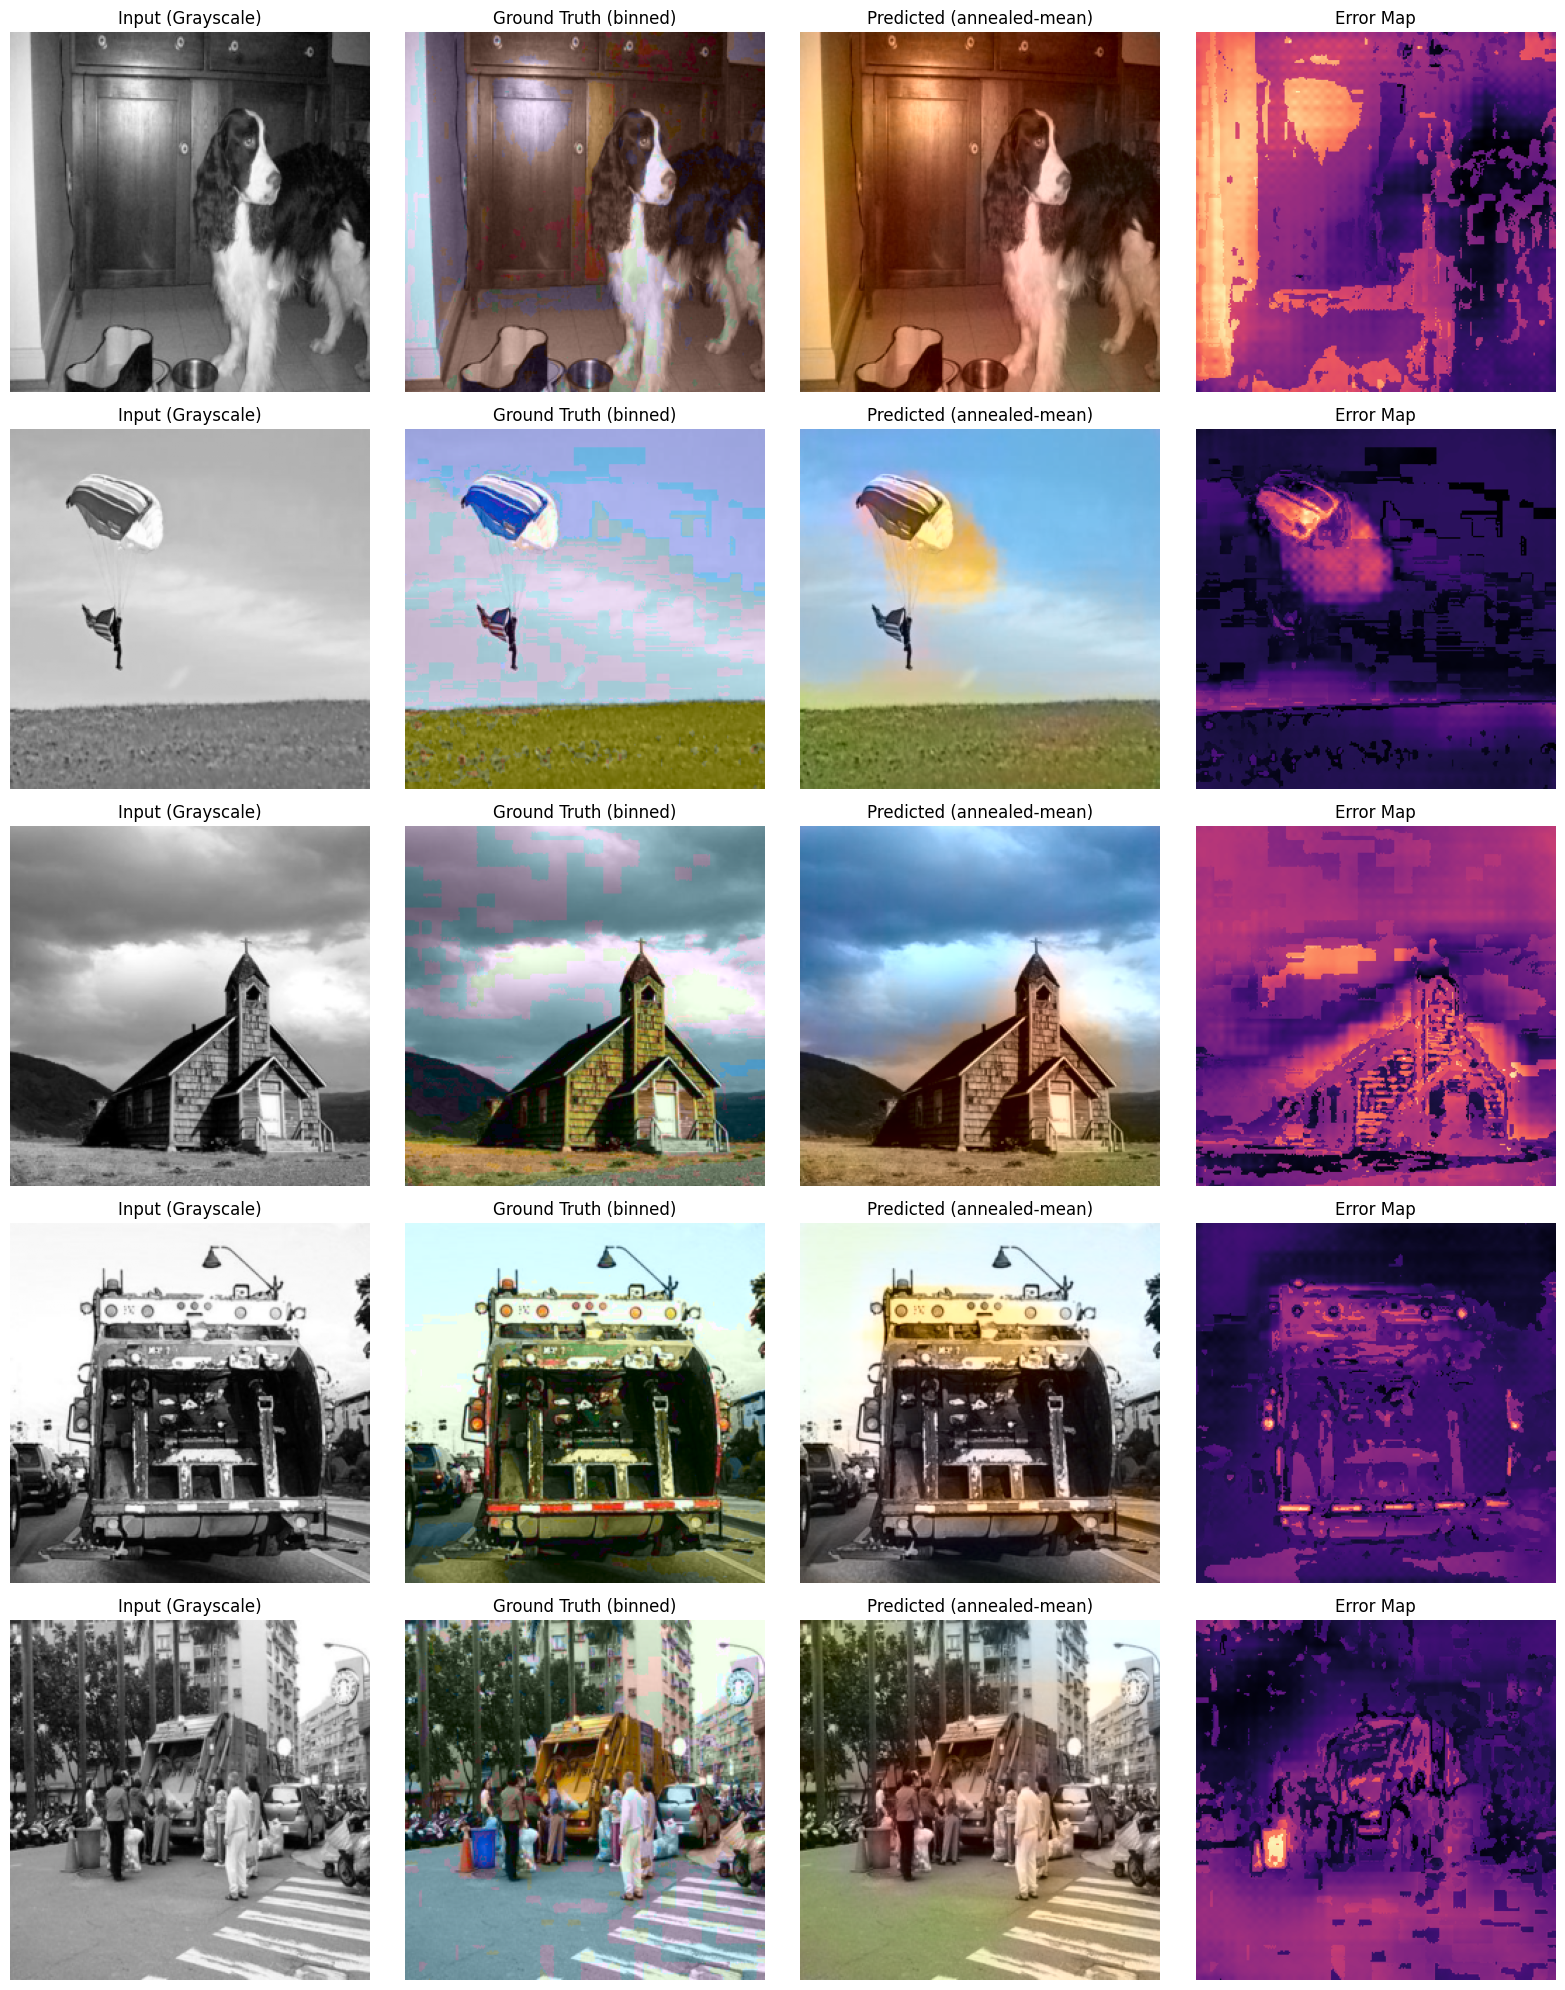

In [19]:
def decode_ab_annealed(logits, pts_ab, T=0.4):
    """
    Decodifica logits de clases de color a canales a,b continuos
    usando annealed-mean con temperatura T.
    """
    # Probabilidades por bin
    probs = F.softmax(logits, dim=1)

    # Aplicar temperatura
    if T != 1.0:
        probs = probs ** (1.0 / T)
        probs = probs / probs.sum(dim=1, keepdim=True).clamp_min(1e-8)
    
    pts_ab = pts_ab.to(logits.device).float()

    ab_pred = torch.einsum('bqhw,qc->bchw', probs, pts_ab)

    return ab_pred

def visualize_colorization(model, dataloader, pts_ab, n_samples=5, device="cuda"):
    """
    Visualiza resultados de colorización usando modelo de CLASIFICACIÓN.

    - model: tu LarssonColorizerClassification
    - dataloader: train/val/test loader
    - pts_ab: tensor (Q, 2) con centros de los bins en UNIDADES LAB REALES
    """

    model.eval()

    # Obtener un batch
    L_batch, q_batch = next(iter(dataloader))
    L_batch = L_batch.to(device)   # (B,1,H,W), L normalizada [0,1]
    q_batch = q_batch.to(device)   # (B,H,W), índices de clase

    with torch.no_grad():
        logits = model(L_batch)    # (B,Q,H,W)
        ab_pred = decode_ab_annealed(logits, pts_ab, T=0.4) # MODIFICACIÓN PARA ANNEALED-MEAN

    pts_ab_np = pts_ab.cpu().numpy()   # (Q,2)

    B = L_batch.shape[0]
    n_samples = min(n_samples, B)

    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))

    for i in range(n_samples):

        # --------------------------
        # 1) L: desnormalizar a [0,100]
        # --------------------------
        L_norm = L_batch[i, 0].cpu().numpy()    # (H,W) en [0,1]
        L_real = L_norm * 100.0                 # (H,W) en [0,100]

        # --------------------------
        # 2) Ground truth aproximado
        # --------------------------
        q_idx_true = q_batch[i].cpu().numpy()   # (H,W)
        # Centros de bin en unidades LAB reales → NO se multiplica por 128
        ab_true = pts_ab_np[q_idx_true]         # (H,W,2)

        # --------------------------
        # 3) Predicción del modelo
        # --------------------------
        # q_idx_pred = torch.argmax(logits[i], dim=0).cpu().numpy()  # (H,W)
        # ab_pred = pts_ab_np[q_idx_pred]                            # (H,W,2)
        ab_pred_np = ab_pred[i].detach().cpu().numpy()
        ab_pred_np = np.transpose(ab_pred_np, (1, 2, 0))    # MODIFICACIÓN PARA ANNEALED-MEAN

        # --------------------------
        # 4) Reconstruir LAB completo
        # --------------------------
        H, W = L_real.shape
        lab_true = np.zeros((H, W, 3), dtype=np.float32)
        lab_pred = np.zeros((H, W, 3), dtype=np.float32)

        lab_true[:, :, 0] = L_real
        lab_true[:, :, 1:] = ab_true

        lab_pred[:, :, 0] = L_real
        lab_pred[:, :, 1:] = ab_pred_np

        # --------------------------
        # 5) Convertir a RGB
        # --------------------------
        rgb_true = lab_to_rgb(lab_true)
        rgb_pred = lab_to_rgb(lab_pred)

        rgb_true = np.clip(rgb_true, 0, 1)
        rgb_pred = np.clip(rgb_pred, 0, 1)

        # --------------------------
        # 6) Mapa de error
        # --------------------------
        error_map = np.linalg.norm(ab_true - ab_pred_np, axis=2)      # (H,W)
        error_map = error_map / (np.max(error_map) + 1e-8)

        # --------------------------
        # 7) Plots
        # --------------------------
        axes[i, 0].imshow(L_real, cmap="gray")
        axes[i, 0].set_title("Input (Grayscale)")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(rgb_true)
        axes[i, 1].set_title("Ground Truth (binned)")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(rgb_pred)
        axes[i, 2].set_title("Predicted (annealed-mean)")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(error_map, cmap="magma")
        axes[i, 3].set_title("Error Map")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

visualize_colorization(
    model_LCC, 
    val_loader, 
    pts_ab=pts_ab_torch, 
    n_samples=5, 
    device=device, 
)

##### Curvas de loss

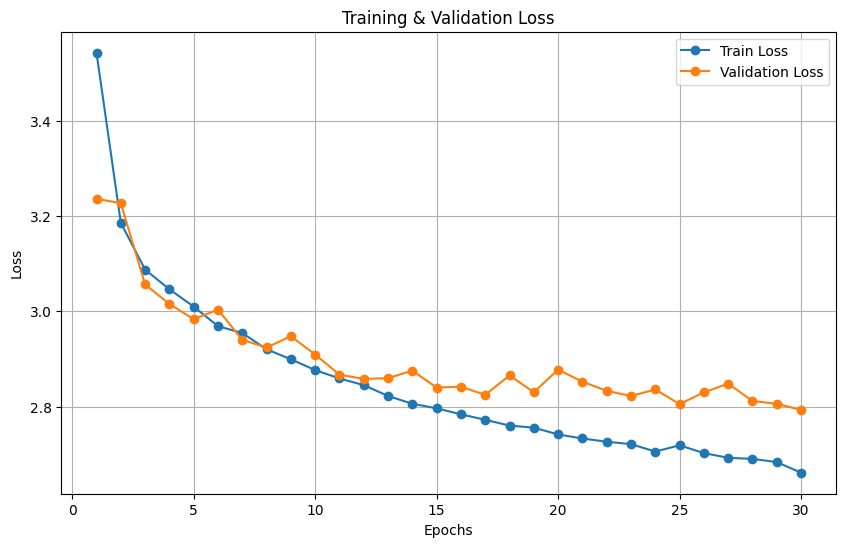

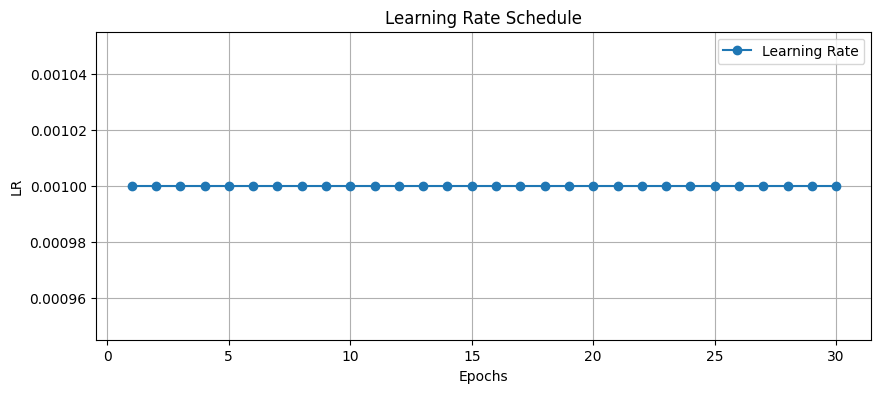

In [20]:
def plot_loss_curves(history):
    """
    Grafica curvas de entrenamiento:
    - train loss
    - validation loss
    - optional: learning rate
    """
    train_loss = history.get("train_loss", None)
    val_loss = history.get("val_loss", None)
    lr = history.get("lr", None)

    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(10, 6))

    # Loss
    plt.plot(epochs, train_loss, label="Train Loss", marker='o')
    plt.plot(epochs, val_loss, label="Validation Loss", marker='o')

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Optional: learning rate curve
    if lr is not None:
        plt.figure(figsize=(10, 4))
        plt.plot(epochs, lr, label="Learning Rate", marker='o')
        plt.xlabel("Epochs")
        plt.ylabel("LR")
        plt.title("Learning Rate Schedule")
        plt.grid(True)
        plt.legend()
        plt.show()

plot_loss_curves(history)

In [21]:
L_batch, q_batch = next(iter(val_loader))
L_batch = L_batch.to(device)
with torch.no_grad():
    logits = model_LCC(L_batch)
    q_pred = torch.argmax(logits, dim=1)   # (B, H, W)

In [22]:
vals_pred, counts_pred = torch.unique(q_pred, return_counts=True)
print("Clases predichas:", len(vals_pred))

Clases predichas: 30


In [23]:
acc = (q_pred == q_batch.to(device)).float().mean().item()
print("Pixel accuracy batch:", acc)

Pixel accuracy batch: 0.20941543579101562


In [24]:
def eval_pixel_accuracy(model, dataloader, device):
    model.eval()
    total_correct = 0
    total_pixels = 0
    with torch.no_grad():
        for L_batch, q_batch in dataloader:
            L_batch = L_batch.to(device)
            q_batch = q_batch.to(device)
            logits = model(L_batch)
            q_pred = torch.argmax(logits, dim=1)
            total_correct += (q_pred == q_batch).sum().item()
            total_pixels  += q_batch.numel()
    return total_correct / total_pixels

acc_val = eval_pixel_accuracy(model_LCC, val_loader, device)
print("Pixel accuracy validación:", acc_val)

Pixel accuracy validación: 0.19909169452756673
